# CODE TO CLASSIFY TRAFFIC SIGNS USING LE-NET ARCHITECTURE IN KERAS

- In this case study, you have been provided with images of traffic signs and the goal is to train a Deep Network to classify them
- The dataset contains 43 different classes of images. 
- Classes are as listed below: 

    - ( 0, b'Speed limit (20km/h)') ( 1, b'Speed limit (30km/h)')
    - ( 2, b'Speed limit (50km/h)') ( 3, b'Speed limit (60km/h)')
    - ( 4, b'Speed limit (70km/h)') ( 5, b'Speed limit (80km/h)')
    - ( 6, b'End of speed limit (80km/h)') ( 7, b'Speed limit (100km/h)')
    - ( 8, b'Speed limit (120km/h)') ( 9, b'No passing')
    - (10, b'No passing for vehicles over 3.5 metric tons')
    - (11, b'Right-of-way at the next intersection') (12, b'Priority road')
    - (13, b'Yield') (14, b'Stop') (15, b'No vehicles')
    - (16, b'Vehicles over 3.5 metric tons prohibited') (17, b'No entry')
    - (18, b'General caution') (19, b'Dangerous curve to the left')
    - (20, b'Dangerous curve to the right') (21, b'Double curve')
    - (22, b'Bumpy road') (23, b'Slippery road')
    - (24, b'Road narrows on the right') (25, b'Road work')
    - (26, b'Traffic signals') (27, b'Pedestrians') (28, b'Children crossing')
    - (29, b'Bicycles crossing') (30, b'Beware of ice/snow')
    - (31, b'Wild animals crossing')
    - (32, b'End of all speed and passing limits') (33, b'Turn right ahead')
    - (34, b'Turn left ahead') (35, b'Ahead only') (36, b'Go straight or right')
    - (37, b'Go straight or left') (38, b'Keep right') (39, b'Keep left')
    - (40, b'Roundabout mandatory') (41, b'End of no passing')
    - (42, b'End of no passing by vehicles over 3.5 metric tons')3
    

# STEP 1: IMPORT LIBRARIES AND DATASET

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import pickle   

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
# The pickle module implements binary protocols for serializing and de-serializing a Python object structure.
with open("./DataSource/train.p", mode='rb') as training_data:
    train = pickle.load(training_data)
with open("./DataSource/valid.p", mode='rb') as validation_data:
    valid = pickle.load(validation_data)
with open("./DataSource/test.p", mode='rb') as testing_data:
    test = pickle.load(testing_data)

In [4]:
X_train,y_train=train['features'],train['labels']
X_validation,y_validation=valid['features'],valid['labels']
X_test,y_test=test['features'],test['labels']

In [5]:
X_train.shape

(34799, 32, 32, 3)

In [6]:
y_train.shape

(34799,)

In [7]:
X_validation.shape

(4410, 32, 32, 3)

In [8]:
y_validation.shape

(4410,)

In [9]:
X_test.shape

(12630, 32, 32, 3)

In [10]:
y_test.shape

(12630,)

# STEP 2: IMAGE EXPLORATION

np.uint8(1)

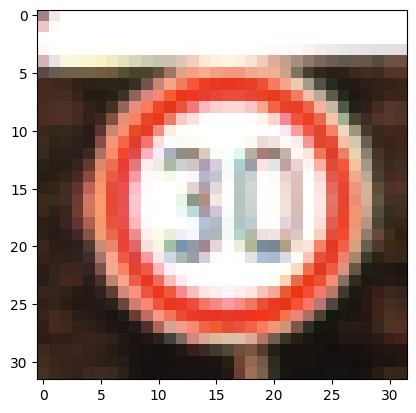

In [11]:
i=3000
plt.imshow(X_train[i])
y_train[i]

np.uint8(7)

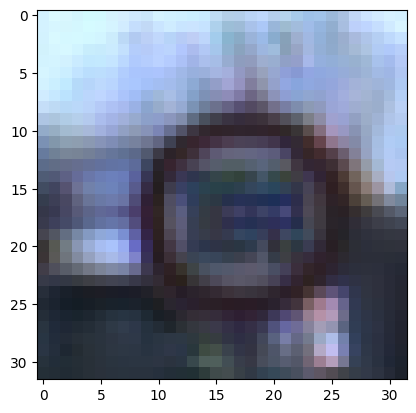

In [12]:
i=3000
plt.imshow(X_validation[i])
y_validation[i]

np.uint8(34)

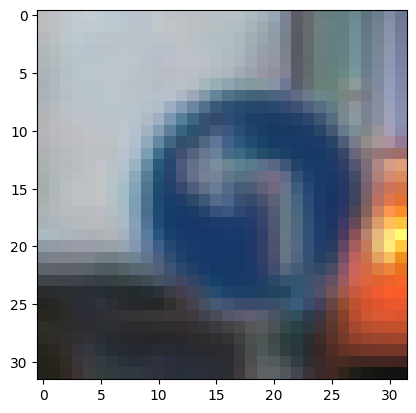

In [13]:
i=2000
plt.imshow(X_test[i])
y_test[i]

# STEP 3: DATA PEPARATION

In [14]:
## shuffle the data 
from sklearn.utils import shuffle
X_train,y_train=shuffle(X_train,y_train)


In [15]:
X_train_gray=np.sum(X_train/3,axis=3,keepdims=True)
X_validation_gray=np.sum(X_validation/3,axis=3,keepdims=True)
X_test_gray=np.sum(X_test/3,axis=3,keepdims=True)

In [16]:
X_train_gray.shape,X_validation_gray.shape,X_test_gray.shape

((34799, 32, 32, 1), (4410, 32, 32, 1), (12630, 32, 32, 1))

In [17]:
#normalization
X_train_gray_norm=(X_train_gray-128)/128
X_validation_gray_norm=(X_validation_gray-128)/128
X_test_gray_norm=(X_test_gray-128)/128

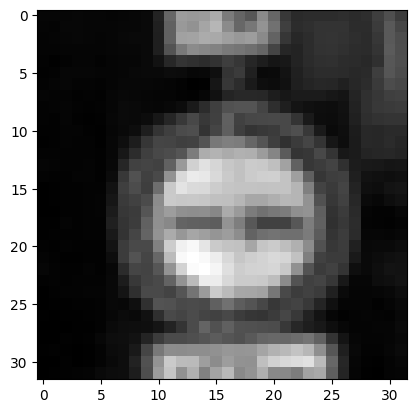

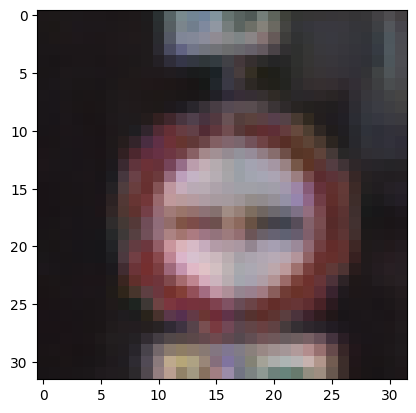

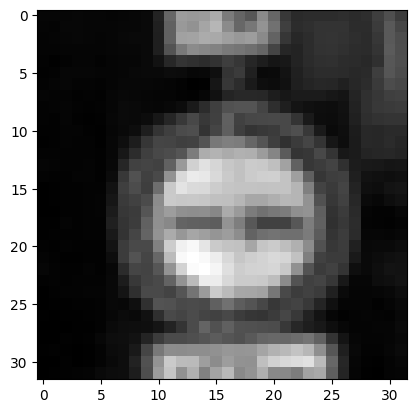

In [18]:
#squeeze function removes single-dimensional entries from the shape of an array.
i=956
plt.imshow(X_train_gray_norm[i].squeeze(),cmap='gray')
plt.figure()
plt.imshow(X_train[i])
plt.figure()
plt.imshow(X_train_gray[i].squeeze(),cmap='gray')

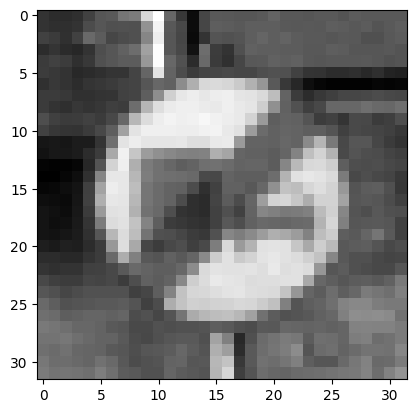

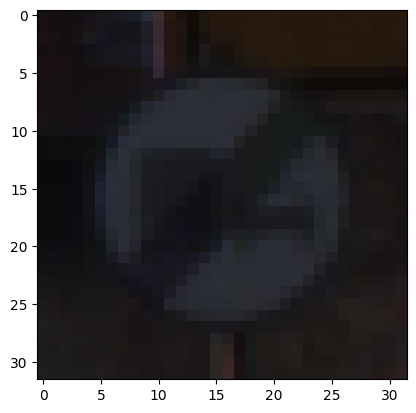

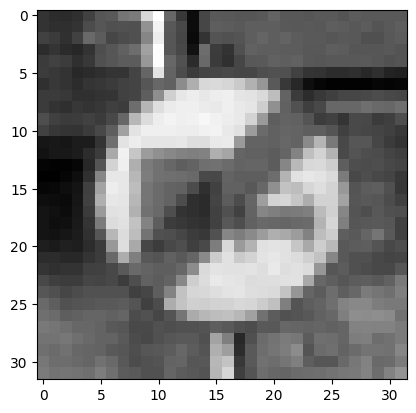

In [19]:
i=956
plt.imshow(X_test_gray_norm[i].squeeze(),cmap='gray')
plt.figure()
plt.imshow(X_test[i])
plt.figure()
plt.imshow(X_test_gray[i].squeeze(),cmap='gray')

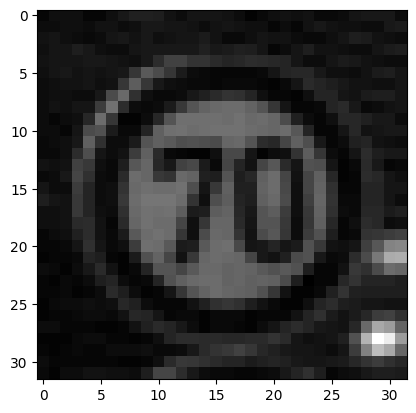

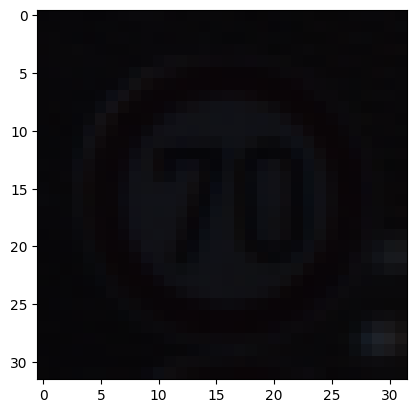

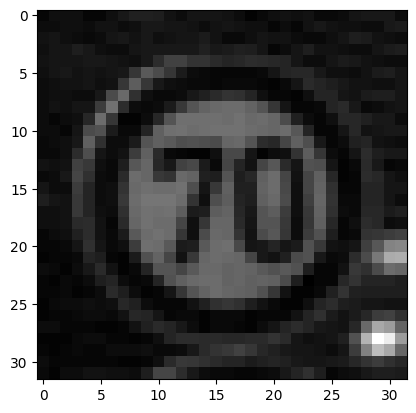

In [20]:
i=956
plt.imshow(X_validation_gray_norm[i].squeeze(),cmap='gray')
plt.figure()
plt.imshow(X_validation[i])
plt.figure()
plt.imshow(X_validation_gray[i].squeeze(),cmap='gray')

# STEP 4: MODEL TRAINING

The model consists of the following layers: 

- STEP 1: THE FIRST CONVOLUTIONAL LAYER #1
    - Input = 32x32x1
    - Output = 28x28x6
    - Output = (Input-filter+1)/Stride* => (32-5+1)/1=28
    - Used a 5x5 Filter with input depth of 3 and output depth of 6
    - Apply a RELU Activation function to the output
    - pooling for input, Input = 28x28x6 and Output = 14x14x6


    * Stride is the amount by which the kernel is shifted when the kernel is passed over the image.

- STEP 2: THE SECOND CONVOLUTIONAL LAYER #2
    - Input = 14x14x6
    - Output = 10x10x16
    - Layer 2: Convolutional layer with Output = 10x10x16
    - Output = (Input-filter+1)/strides => 10 = 14-5+1/1
    - Apply a RELU Activation function to the output
    - Pooling with Input = 10x10x16 and Output = 5x5x16

- STEP 3: FLATTENING THE NETWORK
    - Flatten the network with Input = 5x5x16 and Output = 400

- STEP 4: FULLY CONNECTED LAYER
    - Layer 3: Fully Connected layer with Input = 400 and Output = 120
    - Apply a RELU Activation function to the output

- STEP 5: ANOTHER FULLY CONNECTED LAYER
    - Layer 4: Fully Connected Layer with Input = 120 and Output = 84
    - Apply a RELU Activation function to the output

- STEP 6: FULLY CONNECTED LAYER
    - Layer 5: Fully Connected layer with Input = 84 and Output = 43

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D,AveragePooling2D, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import TensorBoard

In [22]:
cnn_model = Sequential()
cnn_model.add(Conv2D(filters=6, kernel_size=(5,5), activation='relu', input_shape=(32,32,1)))
cnn_model.add(AveragePooling2D(pool_size=(2, 2)))

cnn_model.add(Conv2D(filters=16, kernel_size=(5,5), activation='relu'))
cnn_model.add(AveragePooling2D(pool_size=(2, 2)))

cnn_model.add(Flatten())
cnn_model.add(Dense(120, activation='relu'))
cnn_model.add(Dense(84, activation='relu'))
cnn_model.add(Dense(43, activation='softmax'))



In [23]:
cnn_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 43)             │         3,655 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,511 (252.00 KB)

 Trainable params: 64,511 (252.00 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history=cnn_model.fit(X_train_gray_norm,y_train,
               batch_size=500,epochs=30,verbose=1,validation_data=(X_validation_gray_norm,y_validation))

Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.1841 - loss: 3.1747 - val_accuracy: 0.3141 - val_loss: 2.6618
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5461 - loss: 1.6529 - val_accuracy: 0.6034 - val_loss: 1.3768
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7489 - loss: 0.9052 - val_accuracy: 0.7134 - val_loss: 0.9900
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8260 - loss: 0.6375 - val_accuracy: 0.7649 - val_loss: 0.8213
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8713 - loss: 0.4952 - val_accuracy: 0.7850 - val_loss: 0.7534
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8958 - loss: 0.4031 - val_accuracy: 0.8063 - val_loss: 0.6697
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9093 - loss: 0.3471 - val_accuracy: 0.8272 - val_loss: 0.6167
Epoch 8/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9236 - loss: 0.2960 - val_accuracy: 0.8333 - v

# STEP 5: MODEL EVALUATION

In [25]:
score=cnn_model.evaluate(X_test_gray_norm,y_test,verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.9688594937324524
Test accuracy: 0.8629453778266907


In [26]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [27]:
accuracy=history.history['accuracy']
val_accuracy=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

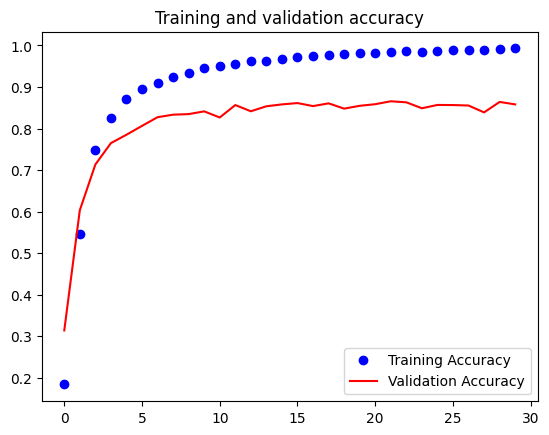

In [28]:
epochs=range(len(accuracy))
plt.plot(epochs,accuracy,'bo',label='Training Accuracy')
plt.plot(epochs,val_accuracy,'r',label='Validation Accuracy')
plt.title('Training and validation accuracy')
plt.legend()

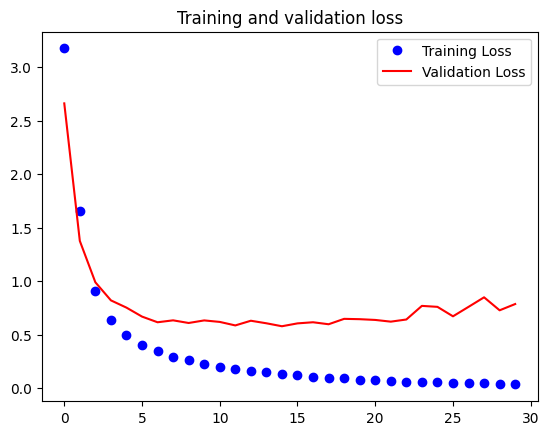

In [33]:
epochs=range(len(loss)) 
plt.plot(epochs,loss,'bo',label='Training Loss')
plt.plot(epochs,val_loss,'r',label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()

In [45]:
predicted_probs=cnn_model.predict(X_test_gray_norm)
predicted_classes=np.argmax(predicted_prods,axis=1)

395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [46]:
print(predicted_probs.shape, predicted_classes.shape, y_test.shape)


(12630, 43) (12630,) (12630,)


In [47]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,predicted_classes)

Text(220.72222222222223, 0.5, 'True Label')

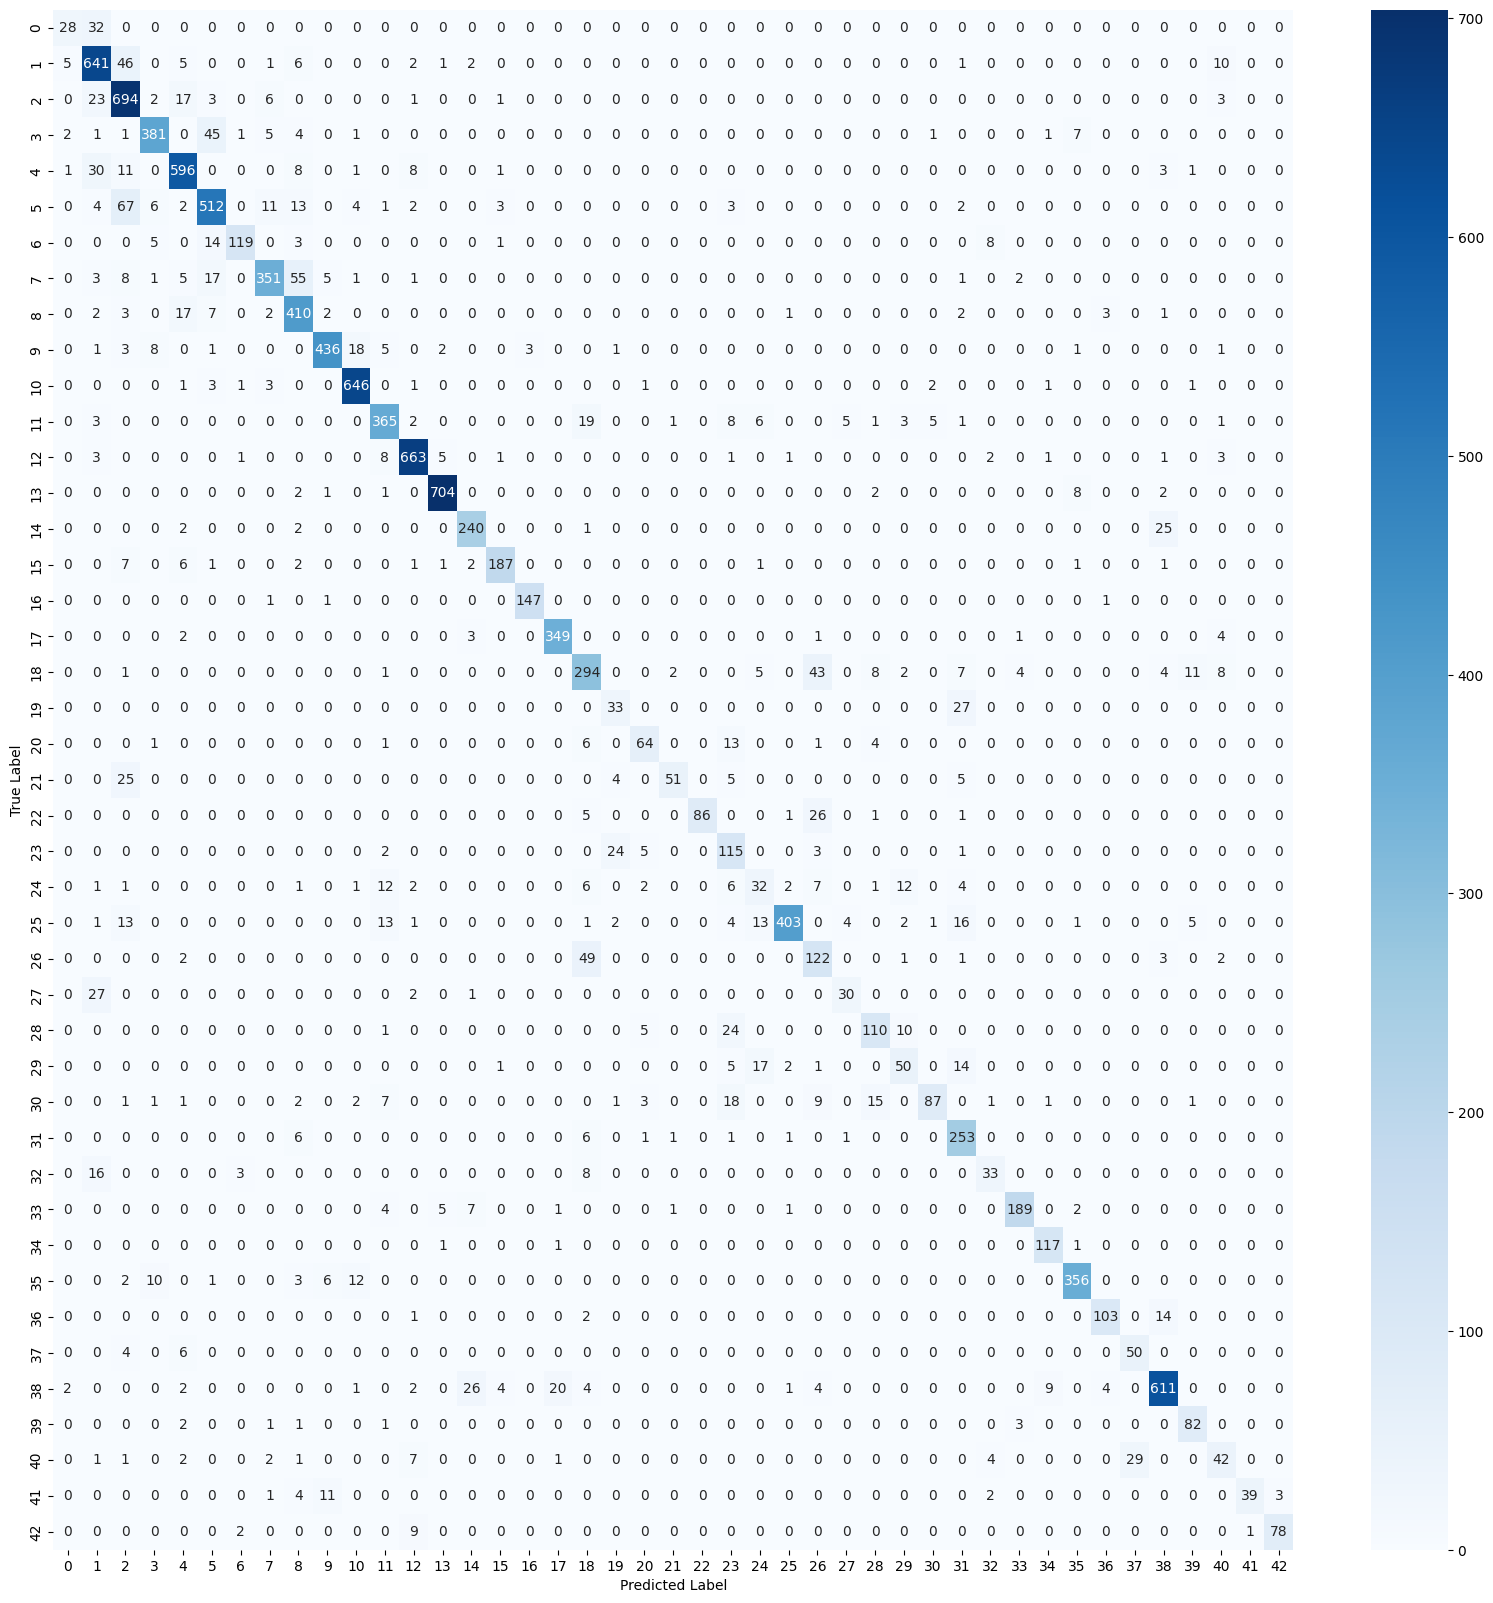

In [55]:
plt.figure(figsize=(20,20))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

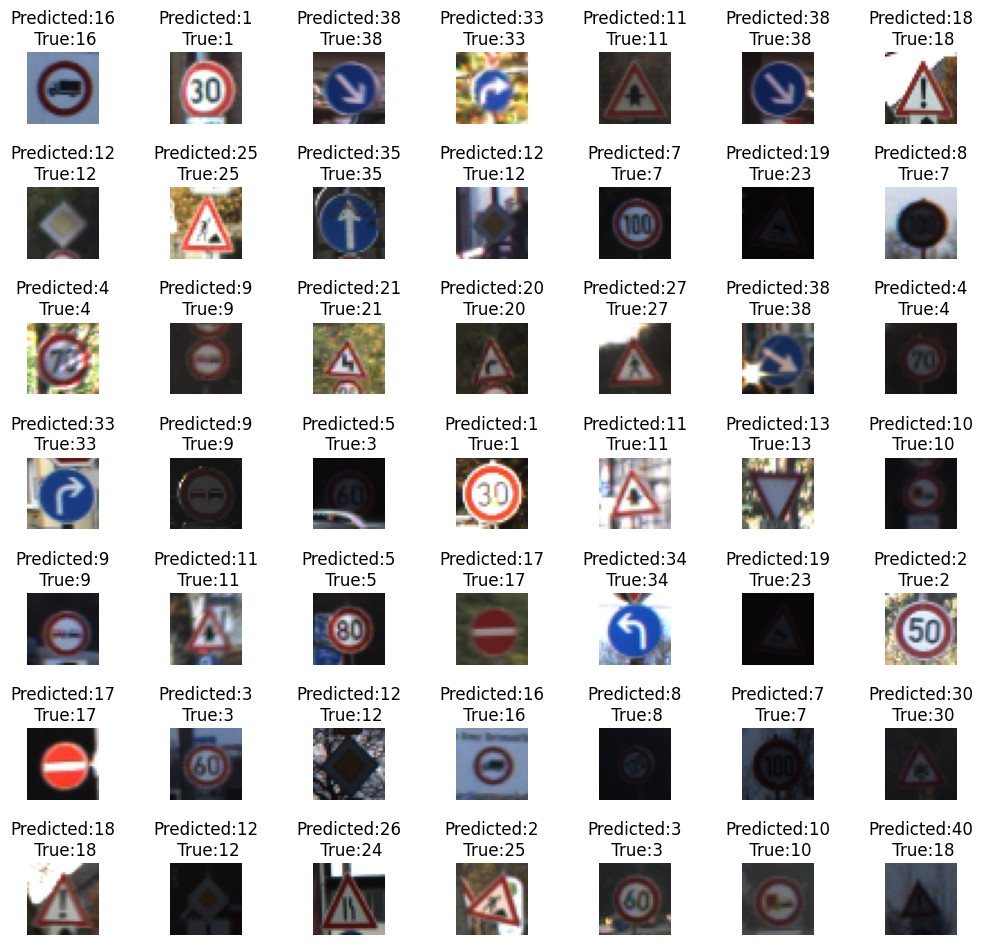

In [62]:
L=7
W=7
fig,axes=plt.subplots(L,W,figsize=(12,12))
axes=axes.ravel()

for i in np.arange(0,L*W):
    axes[i].imshow(X_test[i])
    axes[i].set_title(f"Predicted:{predicted_classes[i]}\n True:{y_test[i]}")
    axes[i].axis('off')

plt.subplots_adjust(wspace=1)